<a href="https://colab.research.google.com/github/MoAbner/YOLO_treino/blob/main/Detec%C3%A7%C3%A3o_de_Fuma%C3%A7a/Wildfire_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Treinamento de detecção de fumaça e fogo para florestas com Ultralytics YOLO

Este notebook foi estruturado para Google Colab e executa o fluxo completo de ponta a ponta: instala dependências, baixa o dataset, treina um detector moderno da família Ultralytics YOLO, avalia os resultados com gráficos e matriz de confusão, e exporta o melhor modelo como `best.onnx` pronto para uso em produção.

Fluxo esperado de execução:
1. Ative GPU no Colab em `Ambiente de execução > Alterar tipo de ambiente de execução > T4 GPU`.
2. Execute as células em ordem, sem pular etapas.
3. Ao final, o arquivo ONNX final ficará disponível em `/content/export/best.onnx`.

## 1. Instalação de dependências

Esta célula instala as bibliotecas usadas no treinamento, análise de métricas, visualização de resultados e exportação ONNX. A versão do Ultralytics é mantida atualizada para permitir uso de modelos recentes da família YOLO.

In [ ]:
%pip install -q --upgrade ultralytics roboflow onnx onnxruntime onnxsim onnxslim pandas seaborn pyyaml pillow scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.5/237.5 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 126.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5

In [ ]:
# Desinstalar e reinstalar Pillow para garantir uma versão estável e compatível.
%pip uninstall -y pillow
%pip install -q pillow==11.0.0

Found existing installation: pillow 12.2.0
Uninstalling pillow-12.2.0:
  Successfully uninstalled pillow-12.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 45.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pi-heif 1.3.0 requires pillow>=11.1.0, but you have pillow 11.0.0 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.


## 2. Configuração do projeto

Esta célula define caminhos, sementes, nome do experimento, hiperparâmetros principais e a fonte do dataset. O notebook usa como padrão o projeto Roboflow `wildfire-smoke-vadpq` do workspace mostrado no notebook de referência. Se necessário, você pode alterar os identificadores do projeto nesta mesma célula.

In [ ]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path.cwd()
RUNS_DIR = PROJECT_DIR / "runs"
EXPORT_DIR = PROJECT_DIR / "export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
RUN_NAME = "wildfire_yolo_colab"

# Configuração padrão do dataset Roboflow baseada no projeto de incêndio florestal do workspace de referência.
ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY", "GTkCvnplkh8sKxneIKXS")
WORKSPACE = "abners-lab"
PROJECT = "wildfire-smoke-vadpq"
VERSION = 1

# Arquitetura base: você pode trocar por yolov8m.pt se quiser aderir estritamente ao YOLOv8.
MODEL_NAME = "yolo11m.pt"
IMG_SIZE = 640
EPOCHS = 80
BATCH = 16
PATIENCE = 20
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print(f"Projeto: {PROJECT_DIR}")
print(f"GPU disponível: {torch.cuda.is_available()}")
print(f"Modelo base: {MODEL_NAME}")
print(f"Roboflow project: {WORKSPACE}/{PROJECT}/{VERSION}")

Projeto: /content
GPU disponível: True
Modelo base: yolo26l.pt
Roboflow project: abners-lab/wildfire-smoke-vadpq/1


## 3. Download e preparação do dataset

Esta célula baixa o dataset no formato YOLO usando a API do Roboflow, carrega o arquivo `data.yaml` e resolve os caminhos reais de treino, validação e teste para uso pelo Ultralytics. Em um ambiente Colab limpo, esta etapa deixa o dataset pronto para treinamento sem intervenção manual.

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
dataset = project.version(VERSION).download("yolov8")

DATASET_DIR = Path(dataset.location)
DATA_YAML = DATASET_DIR / "data.yaml"

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

def resolve_split_path(split_value):
    if split_value is None:
        return None
    split_path = Path(split_value)
    if not split_path.is_absolute():
        split_path = (DATASET_DIR / split_path).resolve()
    return split_path

TRAIN_IMAGES = resolve_split_path(data_config.get("train"))
VAL_IMAGES = resolve_split_path(data_config.get("val"))
TEST_IMAGES = resolve_split_path(data_config.get("test"))
CLASS_NAMES = data_config.get("names", [])

print(f"Dataset salvo em: {DATASET_DIR}")
print(f"Arquivo YAML: {DATA_YAML}")
print(f"Classes: {CLASS_NAMES}")
print(f"Train images: {TRAIN_IMAGES}")
print(f"Val images: {VAL_IMAGES}")
print(f"Test images: {TEST_IMAGES}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Wildfire-Smoke-1 in yolov8:: 100%|██████████| 1479/1479 [00:00<00:00, 3460.15it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset salvo em: /content/Wildfire-Smoke-1
Arquivo YAML: /content/Wildfire-Smoke-1/data.yaml
Classes: ['smoke']
Train images: /content/train/images
Val images: /content/valid/images
Test images: /content/test/images


## 4. Validação dos splits e resumo do dataset

Esta célula verifica a existência dos diretórios esperados, conta imagens e labels por split e calcula a distribuição de classes a partir dos arquivos `.txt` no formato YOLO. Isso ajuda a confirmar se o dataset está consistente antes do treinamento.

In [ ]:
from collections import Counter
from pathlib import Path # Ensure Path is imported in this cell

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# Modified resolve_split_path function to handle Roboflow's data.yaml paths
def resolve_split_path(split_value):
    if split_value is None:
        return None

    # Remove leading '../' if present, as Roboflow's data.yaml often has paths
    # like '../train/images' which should be interpreted relative to DATASET_DIR
    # as 'train/images'.
    if isinstance(split_value, str) and split_value.startswith('../'):
        split_value = split_value[3:] # Remove the first '../'

    split_path = Path(split_value)
    # Now join this corrected relative path with DATASET_DIR
    # DATASET_DIR and data_config are expected to be available from previous cells.
    return (DATASET_DIR / split_path).resolve()

# Re-assign TRAIN_IMAGES, VAL_IMAGES, TEST_IMAGES using the fixed function
# data_config is loaded in a previous cell (09fde414) and should be available.
# DATASET_DIR is defined in a previous cell (09fde414) and should be available.
TRAIN_IMAGES = resolve_split_path(data_config.get('train'))
VAL_IMAGES = resolve_split_path(data_config.get('val'))
TEST_IMAGES = resolve_split_path(data_config.get('test'))

def image_count(images_dir):
    if images_dir is None or not images_dir.exists():
        return 0
    return sum(1 for p in images_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS)

def labels_dir_from_images(images_dir):
    if images_dir is None:
        return None
    if images_dir.name == "images":
        return images_dir.parent / "labels"
    return Path(str(images_dir).replace("images", "labels"))

def collect_label_stats(images_dir):
    labels_dir = labels_dir_from_images(images_dir)
    counter = Counter()
    label_files = []
    if labels_dir and labels_dir.exists():
        label_files = sorted(labels_dir.rglob("*.txt"))
        for label_file in label_files:
            lines = [line.strip() for line in label_file.read_text(encoding="utf-8").splitlines() if line.strip()]
            for line in lines:
                class_id = int(float(line.split()[0]))
                counter[class_id] += 1
    return labels_dir, label_files, counter

split_rows = []
global_counter = Counter()
for split_name, split_dir in [("train", TRAIN_IMAGES), ("val", VAL_IMAGES), ("test", TEST_IMAGES)]:
    if split_dir is None:
        continue
    labels_dir, label_files, counter = collect_label_stats(split_dir)
    global_counter.update(counter)
    split_rows.append({
        "split": split_name,
        "images_dir": str(split_dir),
        "labels_dir": str(labels_dir) if labels_dir else None,
        "num_images": image_count(split_dir),
        "num_label_files": len(label_files),
        "num_boxes": int(sum(counter.values())),
    })

split_df = pd.DataFrame(split_rows)
display(split_df)

class_distribution = pd.DataFrame({
    "class_id": list(global_counter.keys()),
    "class_name": [CLASS_NAMES[idx] if idx < len(CLASS_NAMES) else f"class_{idx}" for idx in global_counter.keys()],
    "annotations": list(global_counter.values()),
}).sort_values("annotations", ascending=False)
display(class_distribution)

assert TRAIN_IMAGES is not None and TRAIN_IMAGES.exists(), "Split de treino não encontrado."
assert VAL_IMAGES is not None and VAL_IMAGES.exists(), "Split de validação não encontrado."
assert image_count(TRAIN_IMAGES) > 0, "Nenhuma imagem encontrada no treino."
assert image_count(VAL_IMAGES) > 0, "Nenhuma imagem encontrada na validação."

,split,images_dir,labels_dir,num_images,num_label_files,num_boxes
0,train,/content/Wildfire-Smoke-1/train/images,/content/Wildfire-Smoke-1/train/labels,516,516,516
1,val,/content/Wildfire-Smoke-1/valid/images,/content/Wildfire-Smoke-1/valid/labels,147,147,147
2,test,/content/Wildfire-Smoke-1/test/images,/content/Wildfire-Smoke-1/test/labels,74,74,73


,class_id,class_name,annotations
0,0,smoke,736


## 5. Visualização rápida de amostras anotadas

Esta célula desenha caixas delimitadoras em algumas imagens do split de treino. O objetivo é validar visualmente se os rótulos de fumaça e fogo estão alinhados com as imagens antes de iniciar o treinamento.

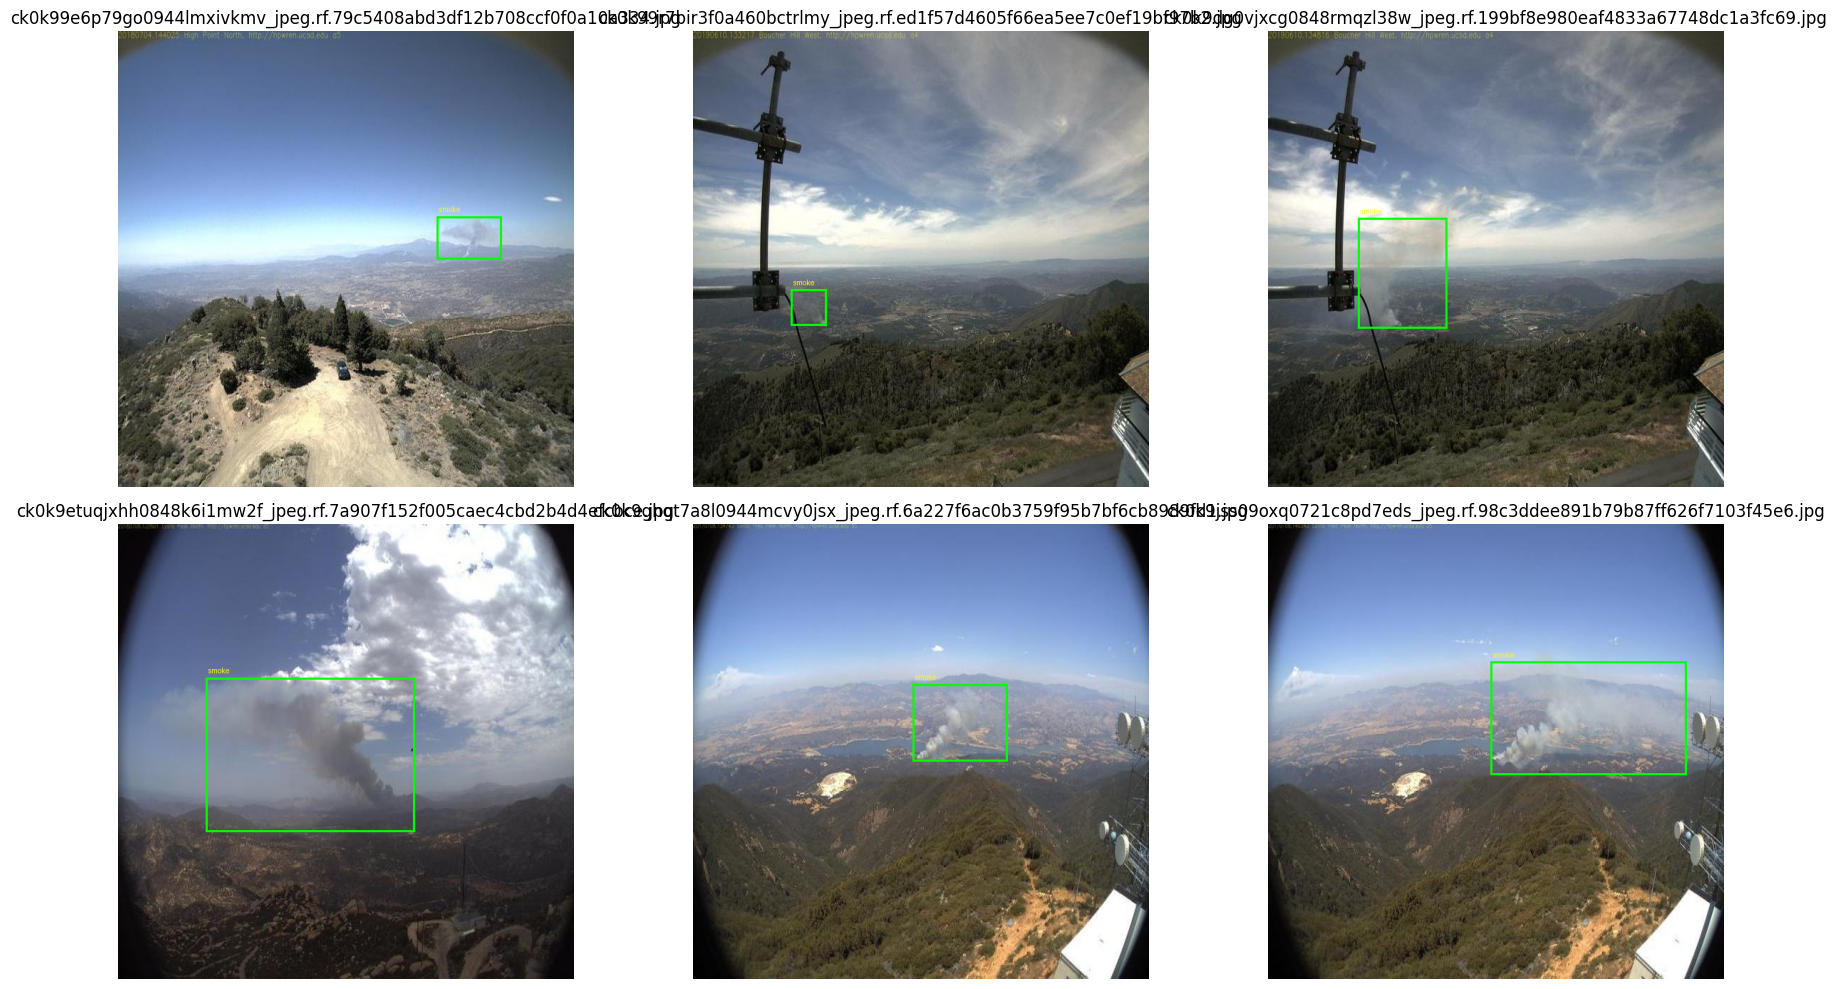

In [ ]:
import math

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

def load_yolo_boxes(label_path, width, height):
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        class_id, x_center, y_center, box_w, box_h = map(float, line.split()[:5])
        x_center *= width
        y_center *= height
        box_w *= width
        box_h *= height
        x1 = x_center - box_w / 2
        y1 = y_center - box_h / 2
        x2 = x_center + box_w / 2
        y2 = y_center + box_h / 2
        boxes.append((int(class_id), x1, y1, x2, y2))
    return boxes

sample_images = sorted([p for p in TRAIN_IMAGES.rglob("*") if p.suffix.lower() in IMAGE_EXTS])[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_images):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    label_path = labels_dir_from_images(image_path.parent) / f"{image_path.stem}.txt"
    for class_id, x1, y1, x2, y2 in load_yolo_boxes(label_path, *image.size):
        draw.rectangle((x1, y1, x2, y2), outline="lime", width=3)
        class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else str(class_id)
        draw.text((x1 + 4, max(0, y1 - 16)), class_name, fill="yellow")
    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

for ax in axes[len(sample_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Configuração do modelo e hiperparâmetros

Esta célula instancia o modelo base e registra explicitamente os hiperparâmetros usados no experimento. As augmentações e regularizações foram escolhidas para melhorar robustez em cenários externos, com variações de iluminação, escala e fundo.

In [ ]:
from ultralytics import YOLO

train_args = {
    "data": str(DATA_YAML),
    "epochs": EPOCHS,
    "imgsz": IMG_SIZE,
    "batch": BATCH,
    "project": str(RUNS_DIR),
    "name": RUN_NAME,
    "device": DEVICE,
    "pretrained": True,
    "optimizer": "AdamW",
    "lr0": 0.001,
    "lrf": 0.01,
    "weight_decay": 0.0005,
    "momentum": 0.937,
    "warmup_epochs": 3.0,
    "patience": PATIENCE,
    "cos_lr": True,
    "amp": True,
    "cache": True,
    "workers": 2,
    "seed": SEED,
    "deterministic": True,
    "close_mosaic": 10,
    "mosaic": 1.0,
    "mixup": 0.1,
    "copy_paste": 0.0,
    "degrees": 5.0,
    "translate": 0.10,
    "scale": 0.40,
    "shear": 2.0,
    "perspective": 0.0005,
    "fliplr": 0.5,
    "flipud": 0.0,
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "erasing": 0.15,
    "dropout": 0.0,
    "plots": True,
    "verbose": True,
    "save": True,
    "save_period": -1,
    "val": True,
    "exist_ok": True,
}

hyperparams_df = pd.DataFrame({
    "hyperparameter": list(train_args.keys()),
    "value": [str(v) for v in train_args.values()],
})
display(hyperparams_df)

model = YOLO(MODEL_NAME)

,hyperparameter,value
0,data,/content/Wildfire-Smoke-1/data.yaml
1,epochs,80
2,imgsz,640
3,batch,16
4,project,/content/runs
5,name,wildfire_yolo_colab
6,device,0
7,pretrained,True
8,optimizer,AdamW
9,lr0,0.001


## 7. Treinamento do detector

Esta célula executa o treinamento completo com logging automático de loss, precision, recall e mAP. O Ultralytics gera artefatos úteis dentro de `runs/`, incluindo curvas de treinamento, batch samples e pesos `best.pt` e `last.pt`.

In [ ]:
train_results = model.train(**train_args)
RUN_DIR = Path(train_results.save_dir)
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"

print(f"Run salvo em: {RUN_DIR}")
print(f"Melhor peso: {BEST_PT}")
print(f"Último peso: {LAST_PT}")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Wildfire-Smoke-1/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.15, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wildfire_yolo_colab, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tr

Exception in thread Thread-24 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    save_handler = SAVE_ALL[format.upper()]
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 843, in _save
    ImageFile._save(
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    """
        
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 461, in 

       1/80      10.7G      2.622       15.3    0.02027         26        640: 3% ──────────── 1/33 2.8s/it 10.4s<1:29

Exception in thread Thread-25 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    save_handler = SAVE_ALL[format.upper()]
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 843, in _save
    ImageFile._save(
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    """
        
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 461, in 

       1/80      10.7G      2.447      14.84    0.01889         24        640: 6% ╸─────────── 2/33 1.7s/it 11.3s<53.6s

...

      71/80      11.1G      1.323     0.5804    0.01142          4        640: 100% ━━━━━━━━━━━━ 33/33 1.2it/s 27.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.8it/s 2.8s
                   all        147        147      0.849      0.898      0.902      0.489

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      72/80      11.1G      1.342     0.6161    0.01176          4        640: 100% ━━━━━━━━━━━━ 33/33 1.3it/s 26.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.7it/s 3.0s
                   all        147        147      0.859      0.871        0.9      0.493

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      73/80        11G      1.309     0.5539      0.011          4        640: 100% ━━━━━━━━━━━━ 33/33 1.3it/s 26.3s
                 Class     Images  Instances      Box(P        

Exception in thread Thread-32 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    save_handler = SAVE_ALL[format.upper()]
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 843, in _save
    ImageFile._save(
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    """
        
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 461, in 

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 60% ━━━━━━━───── 3/5 1.2s/it 2.4s<2.5s

Exception in thread Thread-35 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    save_handler = SAVE_ALL[format.upper()]
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 843, in _save
    ImageFile._save(
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    """
        
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 461, in 

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.3it/s 3.8s
                   all        147        147      0.866      0.878      0.901      0.493
Speed: 0.3ms preprocess, 16.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/wildfire_yolo_colab
Run salvo em: /content/runs/wildfire_yolo_colab
Melhor peso: /content/runs/wildfire_yolo_colab/weights/best.pt
Último peso: /content/runs/wildfire_yolo_colab/weights/last.pt


## 8. Curvas de treinamento e métricas

Esta célula lê o arquivo `results.csv` gerado pelo Ultralytics e plota as principais curvas do experimento. Isso facilita avaliar convergência, estabilidade do treino e evolução de mAP, precision e recall ao longo das épocas.

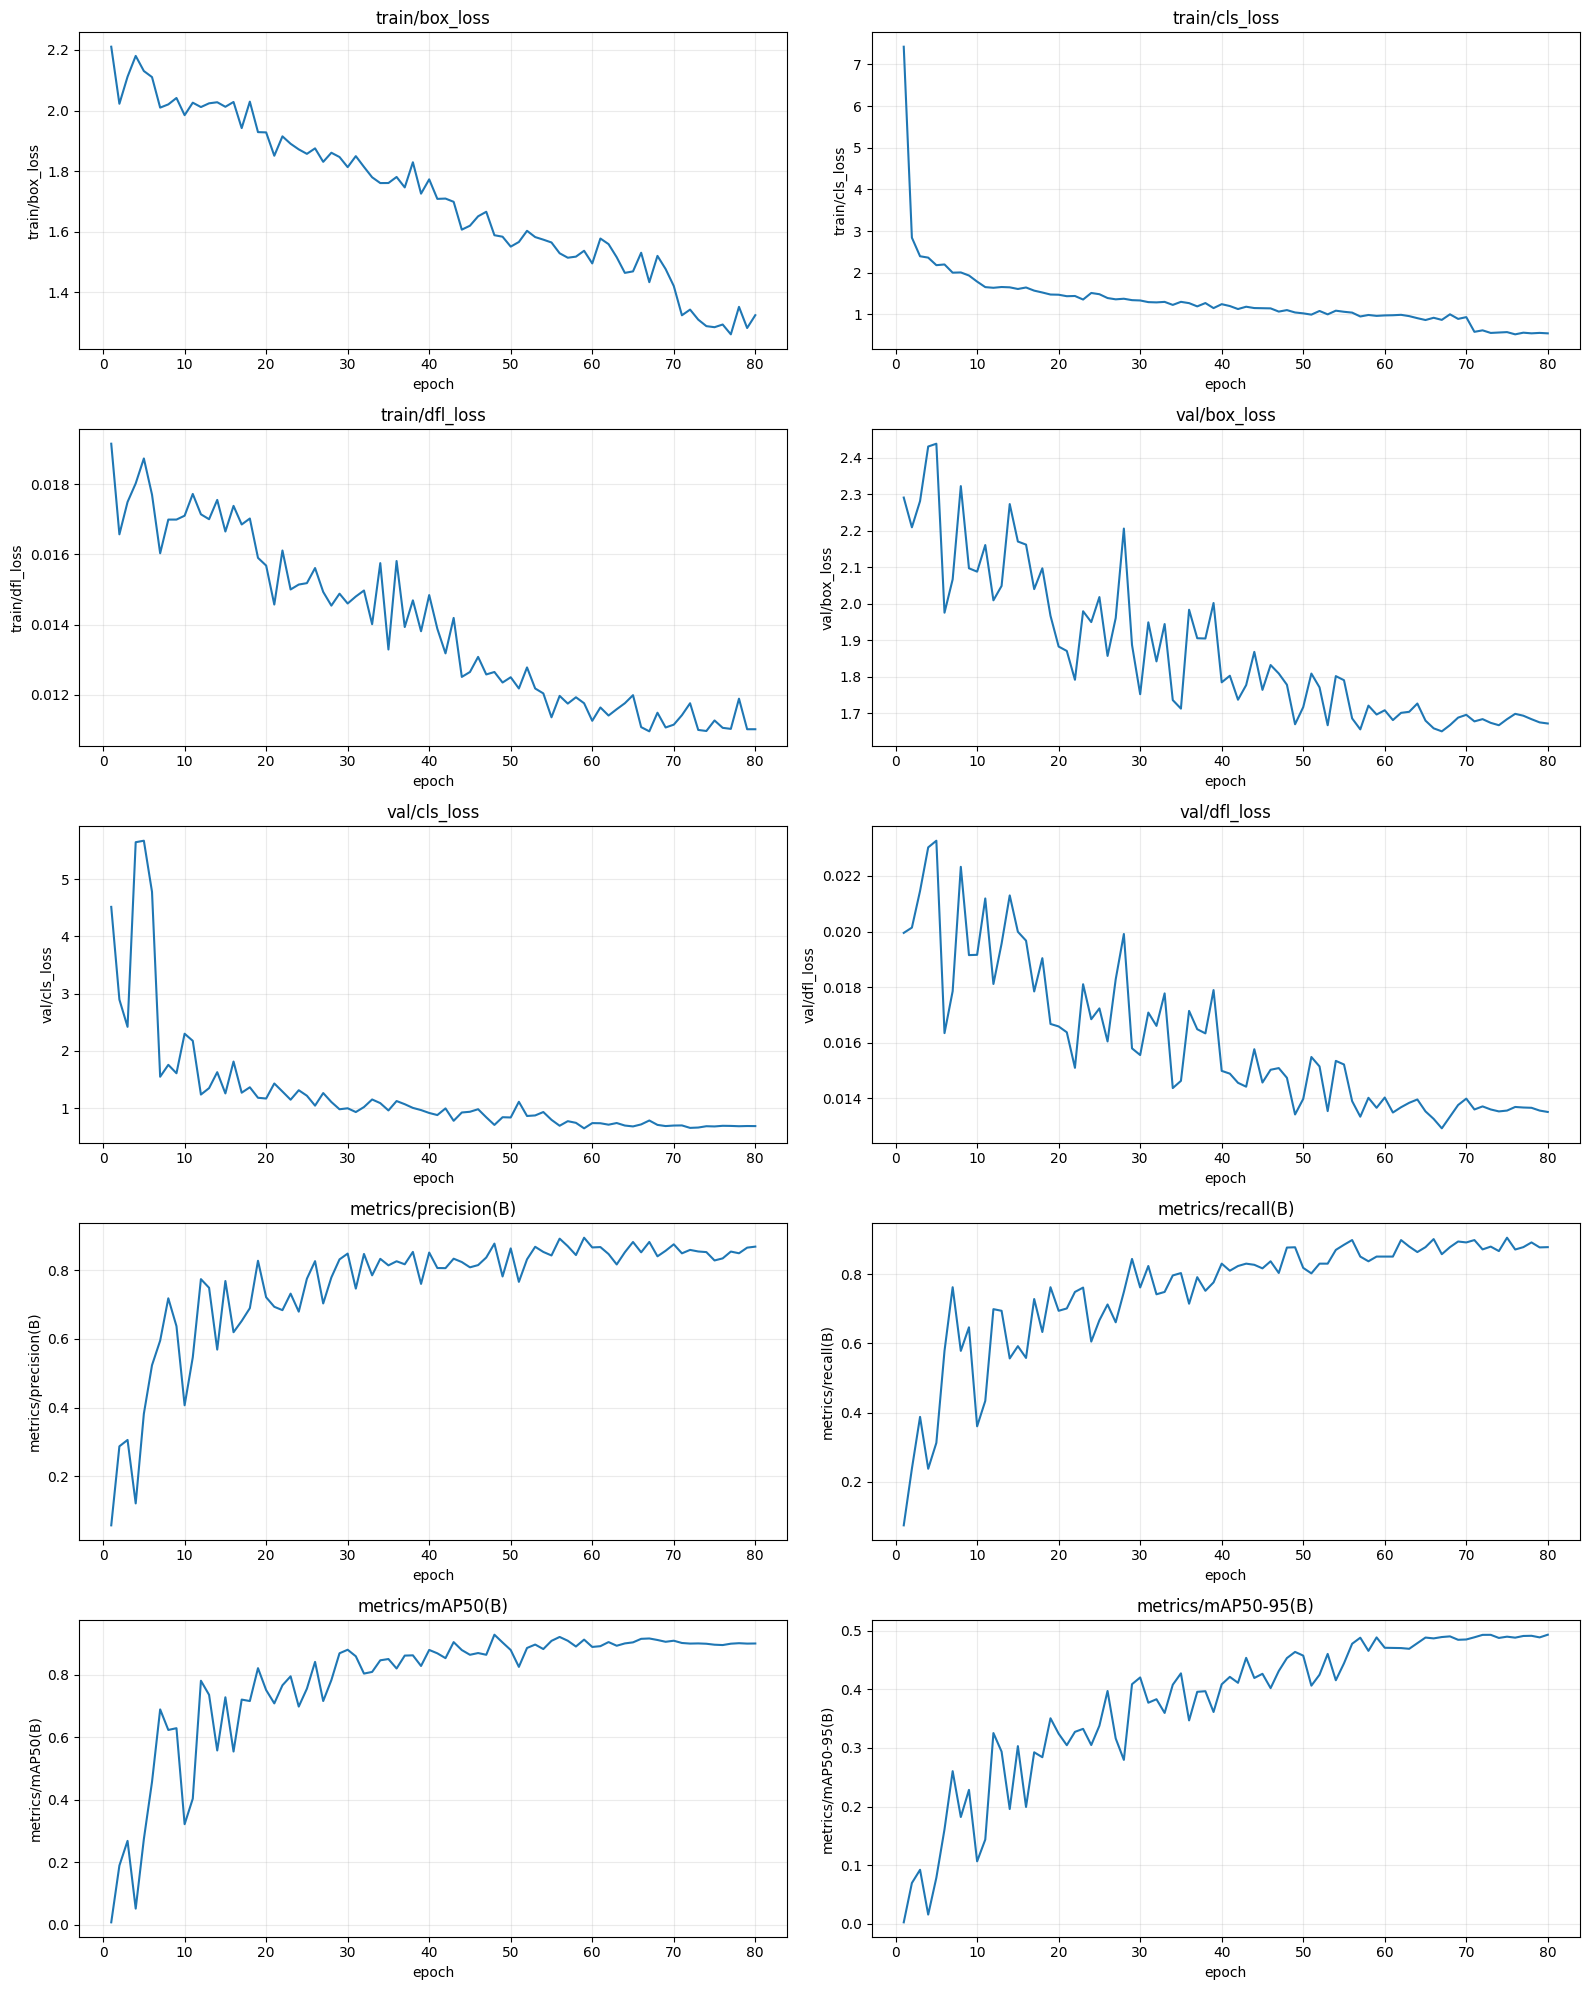

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
75,76,2728.43,1.29298,0.52013,0.01106,0.83442,0.87075,0.89553,0.48812,1.69783,0.69371,0.01368,0.000020,0.000020,0.000020
76,77,2765.31,1.26052,0.56009,0.01103,0.85423,0.87755,0.89988,0.49098,1.69272,0.69166,0.01366,0.000016,0.000016,0.000016
77,78,2802.04,1.35132,0.54411,0.01189,0.84930,0.89116,0.90147,0.49130,1.68320,0.68622,0.01365,0.000013,0.000013,0.000013
78,79,2832.51,1.28143,0.55473,0.01102,0.86568,0.87685,0.90016,0.48856,1.67440,0.68982,0.01355,0.000012,0.000012,0.000012
79,80,2869.79,1.32385,0.54394,0.01102,0.86860,0.87755,0.90052,0.49313,1.67139,0.68845,0.01350,0.000010,0.000010,0.000010


In [ ]:
import seaborn as sns

results_csv = RUN_DIR / "results.csv"
results_df = pd.read_csv(results_csv)
results_df.columns = [col.strip() for col in results_df.columns]

metric_candidates = [
    "train/box_loss", "train/cls_loss", "train/dfl_loss",
    "val/box_loss", "val/cls_loss", "val/dfl_loss",
    "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)",
]
available_metrics = [col for col in metric_candidates if col in results_df.columns]

num_plots = len(available_metrics)
ncols = 2
nrows = math.ceil(num_plots / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, metric_name in zip(axes, available_metrics):
    sns.lineplot(data=results_df, x="epoch", y=metric_name, ax=ax)
    ax.set_title(metric_name)
    ax.grid(True, alpha=0.25)

for ax in axes[len(available_metrics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

display(results_df.tail())

## 9. Avaliação final no melhor checkpoint

Esta célula recarrega o melhor peso do treinamento e executa uma validação final no split de teste quando disponível, ou no split de validação caso o dataset não forneça teste separado. O objetivo é consolidar as métricas finais do modelo selecionado.

In [ ]:
best_model = YOLO(str(BEST_PT))
eval_split = "test" if TEST_IMAGES is not None and TEST_IMAGES.exists() and image_count(TEST_IMAGES) > 0 else "val"
metrics = best_model.val(data=str(DATA_YAML), split=eval_split, imgsz=IMG_SIZE, conf=0.25, iou=0.6, plots=True)

summary = {
    "split": eval_split,
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map),
}
summary_df = pd.DataFrame([summary])
display(summary_df)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 26.6±12.0 MB/s, size: 46.3 KB)
val: Scanning /content/Wildfire-Smoke-1/test/labels... 74 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 449.5it/s 0.2s
val: New cache created: /content/Wildfire-Smoke-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 1/5 2.5s/it 0.7s<9.9s

Exception in thread Thread-42 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    save_handler = SAVE_ALL[format.upper()]
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 843, in _save
    ImageFile._save(
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    """
        
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 461, in 

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 40% ━━━━╸─────── 2/5 1.5s/it 1.5s<4.5s

Exception in thread Thread-44 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    save_handler = SAVE_ALL[format.upper()]
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 843, in _save
    ImageFile._save(
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    """
        
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 461, in 

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 60% ━━━━━━━───── 3/5 1.2s/it 2.3s<2.4s

Exception in thread Thread-46 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    save_handler = SAVE_ALL[format.upper()]
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 843, in _save
    ImageFile._save(
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    """
        
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 461, in 

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.5it/s 3.4s
                   all         74         73      0.946      0.822       0.84      0.449
Speed: 5.0ms preprocess, 35.6ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/val


,split,precision,recall,mAP50,mAP50_95
0,test,0.946133,0.821918,0.840215,0.448623


## 10. Matriz de confusão

Esta célula extrai a matriz de confusão calculada pelo Ultralytics na validação final e a plota em formato normalizado. Para detecção de objetos, a matriz inclui uma classe de fundo para representar falsos positivos e falsos negativos.

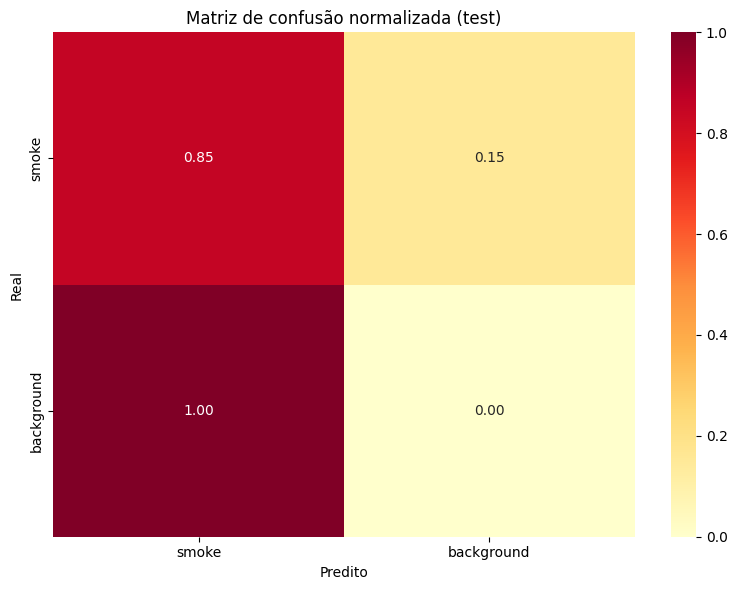

In [ ]:
confusion = metrics.confusion_matrix.matrix.astype(np.float32)
row_sums = confusion.sum(axis=1, keepdims=True)
confusion_norm = np.divide(confusion, row_sums, out=np.zeros_like(confusion), where=row_sums != 0)

cm_labels = list(CLASS_NAMES) + ["background"]

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_norm, annot=True, fmt=".2f", cmap="YlOrRd", xticklabels=cm_labels, yticklabels=cm_labels)
plt.title(f"Matriz de confusão normalizada ({eval_split})")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

## 11. Inspeção qualitativa das previsões

Esta célula executa inferência em algumas imagens do split de avaliação e mostra as previsões do melhor modelo. Essa revisão visual ajuda a entender erros comuns, robustez do detector e qualidade das caixas geradas para fumaça e fogo.

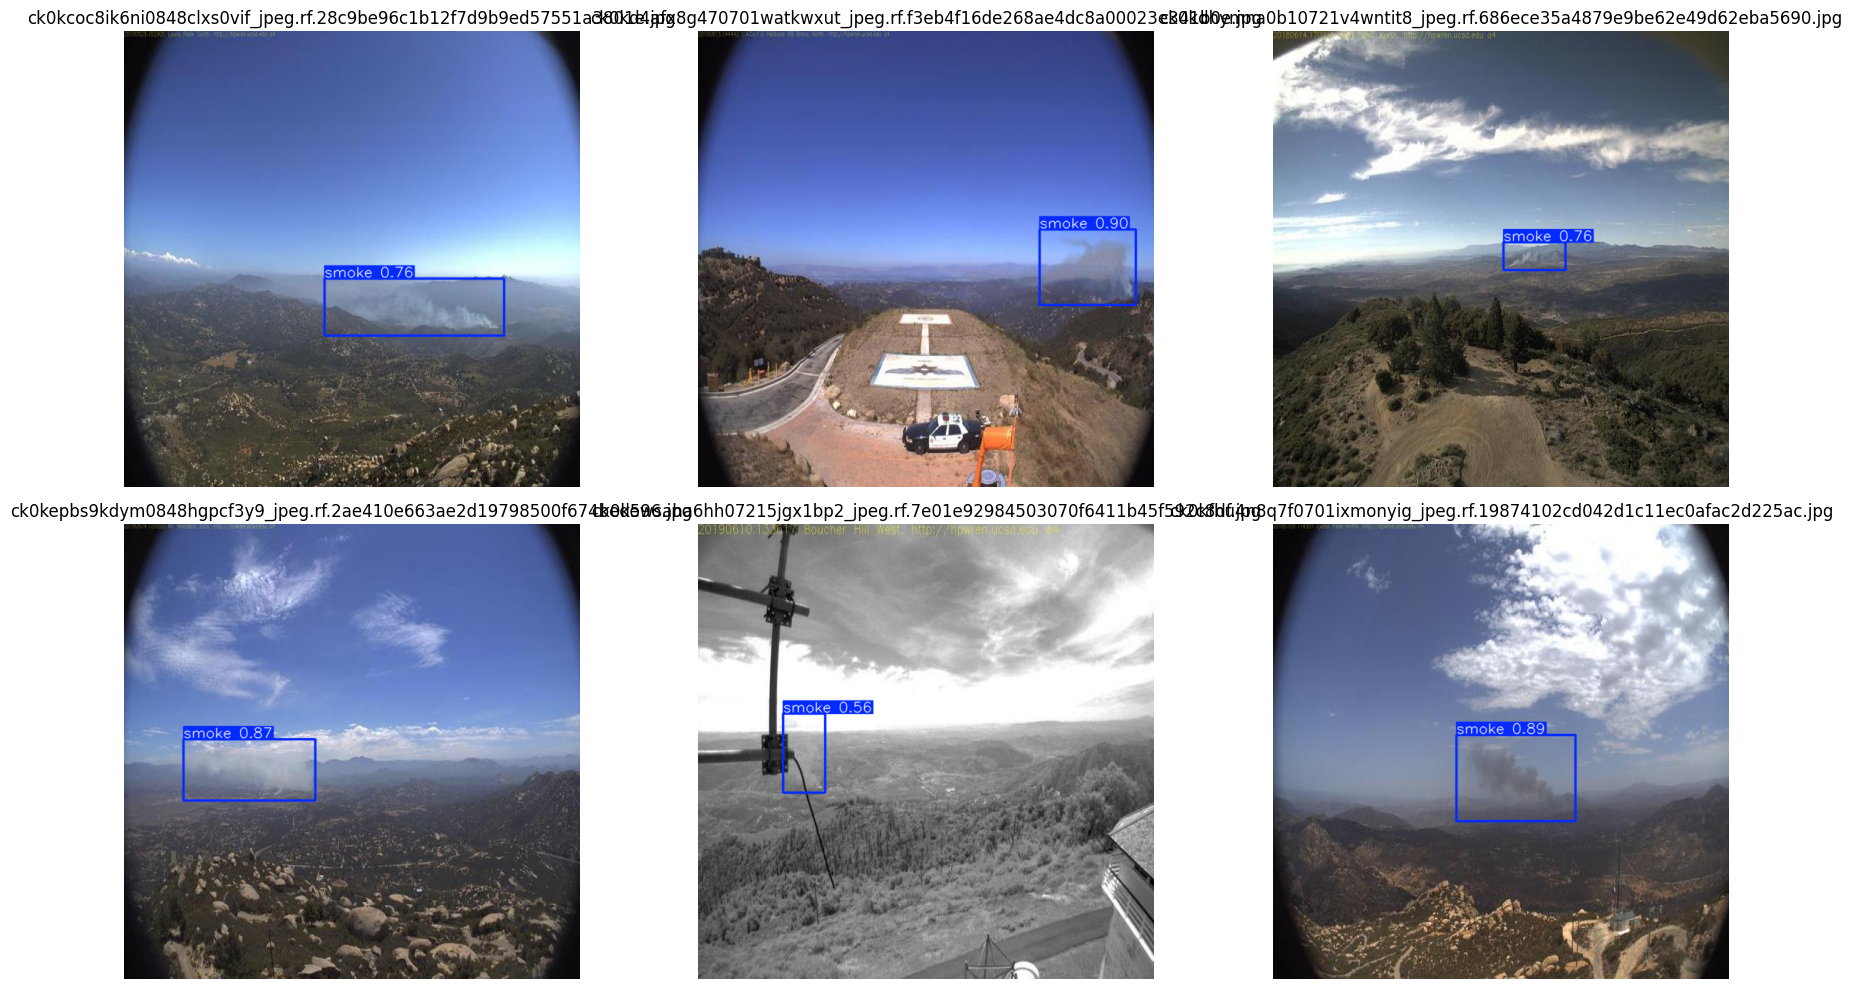

In [ ]:
import cv2

eval_images_dir = TEST_IMAGES if eval_split == "test" else VAL_IMAGES
eval_image_paths = sorted([p for p in eval_images_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS])[:6]
predictions = best_model.predict([str(p) for p in eval_image_paths], imgsz=IMG_SIZE, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, result, image_path in zip(axes, predictions, eval_image_paths):
    plotted = result.plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    ax.imshow(plotted)
    ax.set_title(image_path.name)
    ax.axis("off")

for ax in axes[len(eval_image_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 12. Exportação do melhor modelo para ONNX

Esta célula exporta o melhor checkpoint para ONNX com simplificação do grafo e suporte a eixo dinâmico. Em seguida, ela copia o artefato final para `/content/export/best.onnx`, que é o caminho recomendado para baixar ou integrar em produção.

In [ ]:
exported_path = Path(best_model.export(format="onnx", imgsz=IMG_SIZE, opset=12, simplify=True, dynamic=True))
FINAL_ONNX = EXPORT_DIR / "best.onnx"
shutil.copy2(exported_path, FINAL_ONNX)

print(f"Arquivo ONNX exportado: {exported_path}")
print(f"Arquivo final pronto para produção: {FINAL_ONNX}")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/wildfire_yolo_colab/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (50.5 MB)
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 5 packages in 231ms
Prepared 1 package in 10.31s
Installed 1 package in 50ms
 + onnxruntime-gpu==1.25.1

requirements: AutoUpdate success ✅ 11.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...


Exporting aten::index operator of advanced indexing in opset 12 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 18.5s, saved as '/content/runs/wildfire_yolo_colab/weights/best.onnx' (95.9 MB)

Export complete (21.3s)
Results saved to /content/runs/wildfire_yolo_colab/weights
Predict:         yolo predict task=detect model=/content/runs/wildfire_yolo_colab/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/wildfire_yolo_colab/weights/best.onnx imgsz=640 data=/content/Wildfire-Smoke-1/data.yaml  
Visualize:       https://netron.app
Arquivo ONNX exportado: /content/runs/wildfire_yolo_colab/weights/best.onnx
Arquivo final pronto para produção: /content/export/best.onnx


## 13. Verificação do arquivo ONNX

Esta célula valida a integridade do modelo exportado, abre uma sessão do ONNX Runtime e imprime entradas e saídas do grafo. Isso reduz o risco de terminar o notebook com um arquivo inválido para inferência.

In [ ]:
import onnx
import onnxruntime as ort

onnx_model = onnx.load(str(FINAL_ONNX))
onnx.checker.check_model(onnx_model)

providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if torch.cuda.is_available() else ["CPUExecutionProvider"]
ort_session = ort.InferenceSession(str(FINAL_ONNX), providers=providers)

print("ONNX validado com sucesso.")
print("Entradas:")
for inp in ort_session.get_inputs():
    print(f"- {inp.name}: shape={inp.shape}, type={inp.type}")
print("Saídas:")
for out in ort_session.get_outputs():
    print(f"- {out.name}: shape={out.shape}, type={out.type}")

ONNX validado com sucesso.
Entradas:
- images: shape=['batch', 3, 'height', 'width'], type=tensor(float)
Saídas:
- output0: shape=['batch', 300, 6], type=tensor(float)


## 14. Conclusão

Se todas as células executarem com sucesso, o notebook terá produzido:
- pesos treinados em `runs/wildfire_yolo_colab/weights/`
- gráficos e artefatos de avaliação no diretório do experimento
- modelo final em `/content/export/best.onnx`

Para baixar o arquivo no Colab, navegue até o painel de arquivos e localize `export/best.onnx`.